In [4]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [5]:
train = pd.read_csv('../data/raw/train.csv')
stores = pd.read_csv('../data/raw/stores.csv')
oil = pd.read_csv('../data/raw/oil.csv')
holidays = pd.read_csv('../data/raw/holidays_events.csv')

In [6]:
train['date'] = pd.to_datetime(train['date'])
oil['date'] = pd.to_datetime(oil['date'])
holidays['date'] = pd.to_datetime(holidays['date'])

In [7]:
df = train.merge(stores, on='store_nbr', how='left')
df = df.merge(oil , on='date',how='left')
df = df.merge(holidays , on='date',how='left')

In [8]:
df.isnull().sum().sort_values(ascending=False)

type_y         2551824
locale         2551824
locale_name    2551824
description    2551824
transferred    2551824
dcoilwtico      955152
id                   0
date                 0
store_nbr            0
family               0
sales                0
onpromotion          0
city                 0
state                0
type_x               0
cluster              0
dtype: int64

In [9]:
df['dcoilwtico'] = df['dcoilwtico'].ffill()

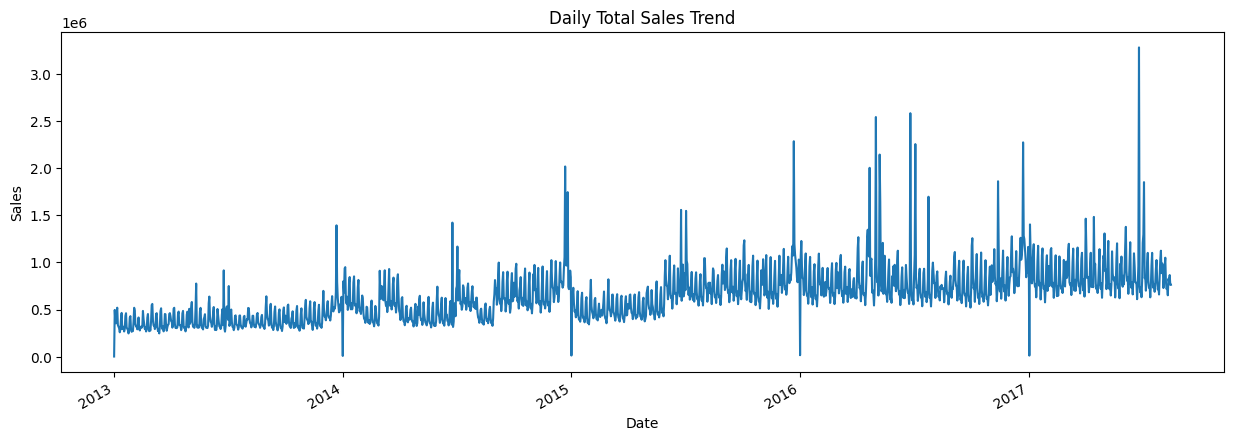

In [10]:
daily_sales = df.groupby("date")["sales"].sum()

plt.figure(figsize=(15,5))
daily_sales.plot()
plt.title("Daily Total Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

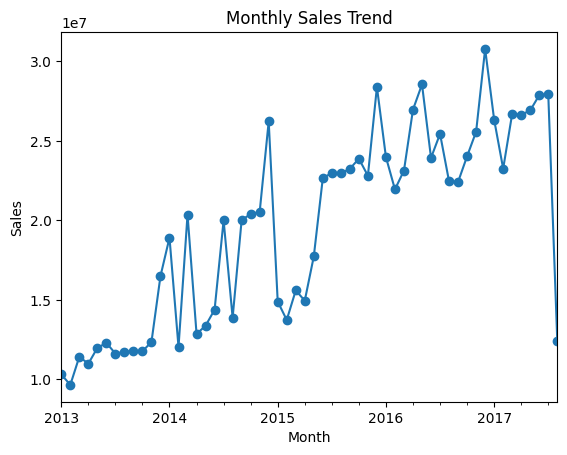

In [11]:
monthly_sales = df.groupby(df["date"].dt.to_period("M"))["sales"].sum()

monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

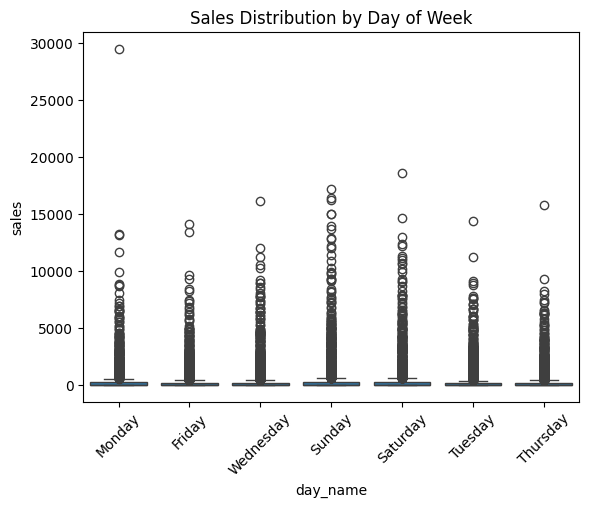

In [12]:
df["day_name"] = df["date"].dt.day_name()

sns.boxplot(x="day_name", y="sales", data=df.sample(20000))
plt.title("Sales Distribution by Day of Week")
plt.xticks(rotation=45)
plt.show()

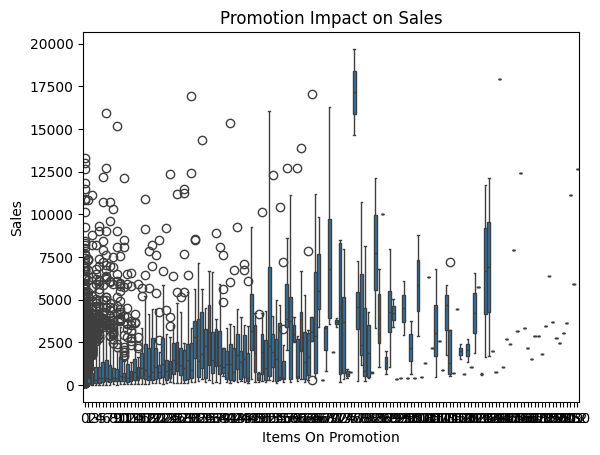

In [24]:
promo_sample = df.sample(20000)

sns.boxplot(x="onpromotion", y="sales", data=promo_sample)
plt.title("Promotion Impact on Sales")
plt.xlabel("Items On Promotion")
plt.ylabel("Sales")
plt.show()

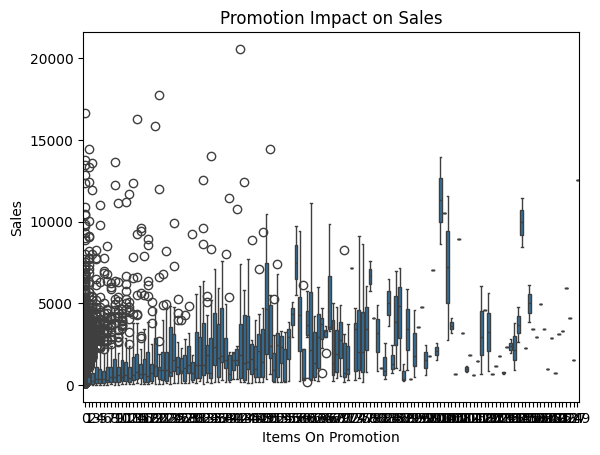

In [13]:
promo_sample = df.sample(20000)

sns.boxplot(x="onpromotion", y="sales", data=promo_sample)
plt.title("Promotion Impact on Sales")
plt.xlabel("Items On Promotion")
plt.ylabel("Sales")
plt.show()

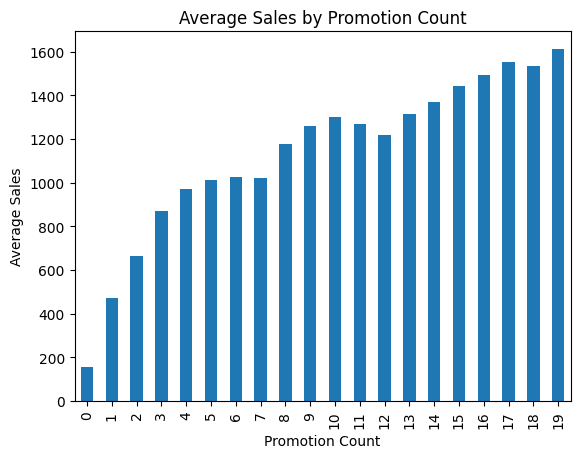

In [14]:
promo_effect = df.groupby("onpromotion")["sales"].mean().head(20)

promo_effect.plot(kind="bar")
plt.title("Average Sales by Promotion Count")
plt.xlabel("Promotion Count")
plt.ylabel("Average Sales")
plt.show()

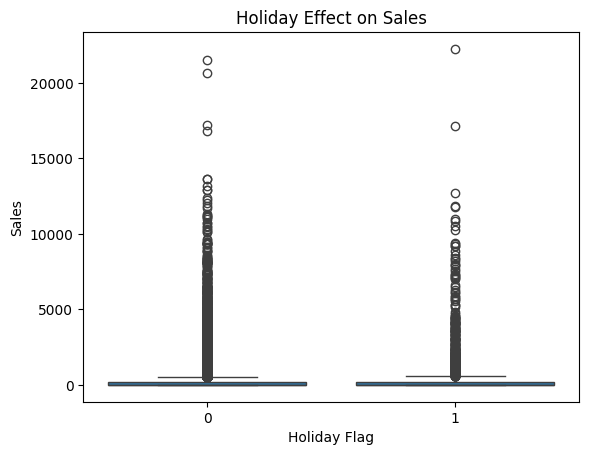

In [16]:
df['holiday_flag'] = df['type_y'].notna().astype(int)

sns.boxplot(x="holiday_flag", y="sales", data=df.sample(20000))
plt.title("Holiday Effect on Sales")
plt.xlabel("Holiday Flag")
plt.ylabel("Sales")
plt.show()

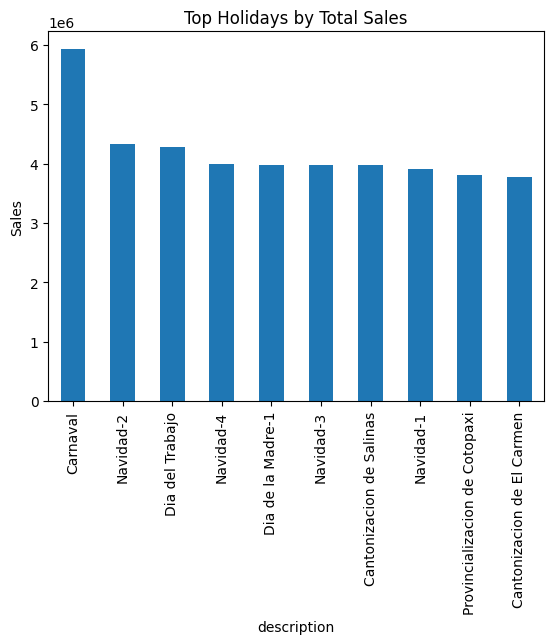

In [17]:
holiday_sales = (
    df[df["holiday_flag"] == 1]
    .groupby("description")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

holiday_sales.plot(kind="bar")
plt.title("Top Holidays by Total Sales")
plt.ylabel("Sales")
plt.show()

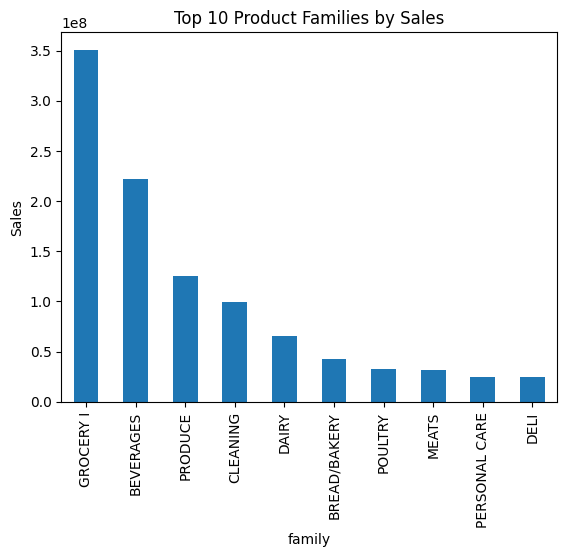

In [18]:
top_products = (
    df.groupby("family")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(kind="bar")
plt.title("Top 10 Product Families by Sales")
plt.ylabel("Sales")
plt.show()

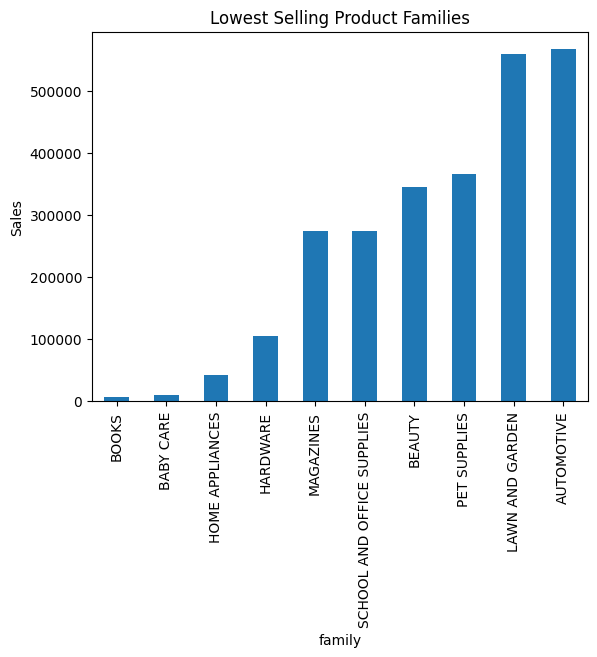

In [19]:
low_products = (
    df.groupby("family")["sales"]
    .sum()
    .sort_values()
    .head(10)
)

low_products.plot(kind="bar")
plt.title("Lowest Selling Product Families")
plt.ylabel("Sales")
plt.show()

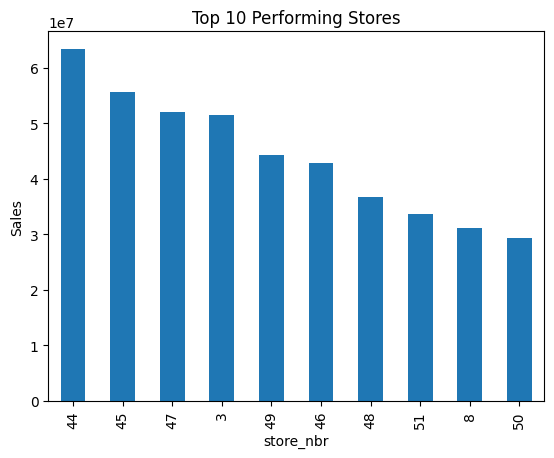

In [20]:
top_stores = (
    df.groupby("store_nbr")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_stores.plot(kind="bar")
plt.title("Top 10 Performing Stores")
plt.ylabel("Sales")
plt.show()

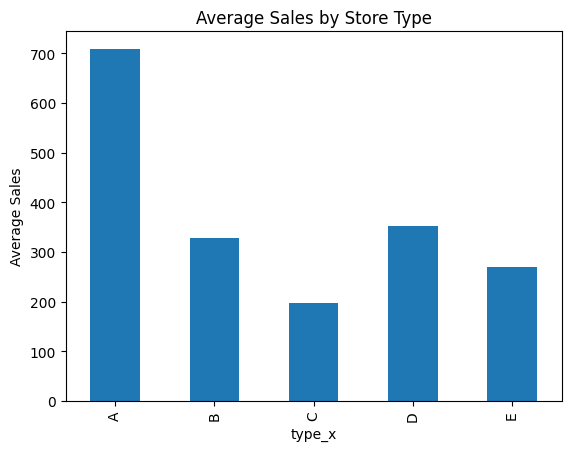

In [21]:
store_type_sales = df.groupby("type_x")["sales"].mean()

store_type_sales.plot(kind="bar")
plt.title("Average Sales by Store Type")
plt.ylabel("Average Sales")
plt.show()

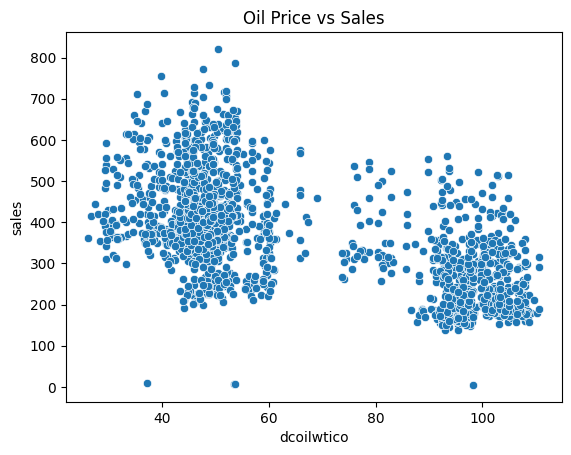

In [22]:
oil_sales = df.groupby("date")[["sales", "dcoilwtico"]].mean()

sns.scatterplot(
    x="dcoilwtico",
    y="sales",
    data=oil_sales
)
plt.title("Oil Price vs Sales")
plt.show()

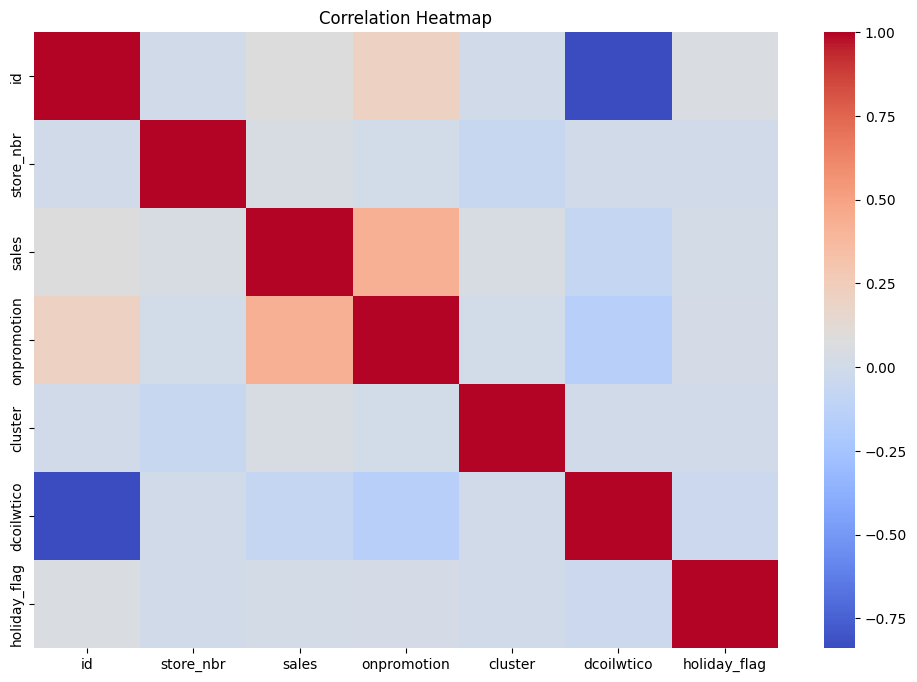

In [23]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=False
)
plt.title("Correlation Heatmap")
plt.show()